In [15]:
# In this section I am importing all the libraries I will need
import numpy as np
import matplotlib.pyplot as plt
from scipy.fftpack import fft, fftfreq


In [16]:
# In this section I am defining variables (arrays) that I would need to implement the method

#const
Lx, Ly = 10.0, 10.0     # size of room
Nx, Ny = 80, 80         # num of grid points
dx = Lx / (Nx - 1)      
dy = dx    
c = 343.0                 # speed of sound

dt = 0.0002 # temporal increment
tend = 0.1  # temporal span
Nt = int(tend / dt)
C= c * dt / dx  # Courant number

#create matrix:
x = np.linspace(0, Lx, Nx)
y = np.linspace(0, Ly, Ny)
X, Y = np.meshgrid(x, y) #This is so easier to cal IC
P = np.zeros((Nt,Nx,Ny))

A = 100.0     # amplitude of the pulse
sigma = 0.5   # width of the pulse

# position of the speaker
xc1, yc1 = 2.0, 8.0  # top left corner
xc2, yc2 = 8.0, 8.0  # top right corner


In [17]:
# In this section I am setting the boundary conditions/initial values

#INITIAL CONDITION
P[0, :, :] = (A * np.exp(-((X - xc1)**2 + (Y - yc1)**2) / (2 * sigma**2)) + 
              A * np.exp(-((X - xc2)**2 + (Y - yc2)**2) / (2 * sigma**2)))

for x in range(1,Nx-1): #find pressure field at n=1 for the center using IC equation
    for y in range(1,Ny-1):
        P[1, x, y] = P[0, x, y] + (C**2 / 2) * (
            P[0, x, y+1] + P[0, x, y-1] + P[0, x+1, y] + P[0, x-1, y] - 4 * P[0, x, y]
        )

#BOUNDARY CONDITION at n=1 time step ONLY
P[1, 0, :] = P[1, 1, :]       # y=0
P[1, -1, :] = P[1, -2, :]     # y=Ly
P[1, :, 0] = P[1, :, 1]       # x=0
P[1, :, -1] = P[1, :, -2]     # x=Lx


In [18]:
# In this section I am implementing the numerical method

#SOLVE for n>1 time steps, BC AND VALS
for n in range(2, Nt): #for all time steps except the first two
    for x in range(1, Nx - 1): # for all interior points
        for y in range(1, Ny - 1):
            # Update the pressure field using the finite difference scheme
            P[n, x, y] = 2 * P[n-1, x, y] - P[n-2, x, y] + C**2 * (
                P[n-1, x, y+1] + P[n-1, x, y-1] + P[n-1, x+1, y] + P[n-1, x-1, y] - 4 * P[n-1, x, y]
            )
    
    #BOUNDARY CONDITION at n>1 (rigid walls, zero normal gradient)
    P[n, 0, :] = P[n, 1, :]       # Bottom wall
    P[n, -1, :] = P[n, -2, :]     # Top wall
    P[n, :, 0] = P[n, :, 1]       # Left wall
    P[n, :, -1] = P[n, :, -2]     # Right wall


In [19]:
# In this section I am doing any post-processing (if needed)

# Extract the pressure field at a specific time step for plotting
plot_time = 0.05  # time at which to plot
plot_step = int(plot_time / dt)  # corresponding time step index

# extract history of P at center of room (virtual microphone)
mic_x_idx, mic_y_idx = Nx // 2, Ny // 2
mic_history = P[:, mic_y_idx, mic_x_idx]
time_array = np.linspace(0, tend, Nt)

# FFT Analysis of microphone signal to identify resonant frequencies
N_fft = len(mic_history)
yf = fft(mic_history)
xf = fftfreq(N_fft, dt)[:N_fft//2]


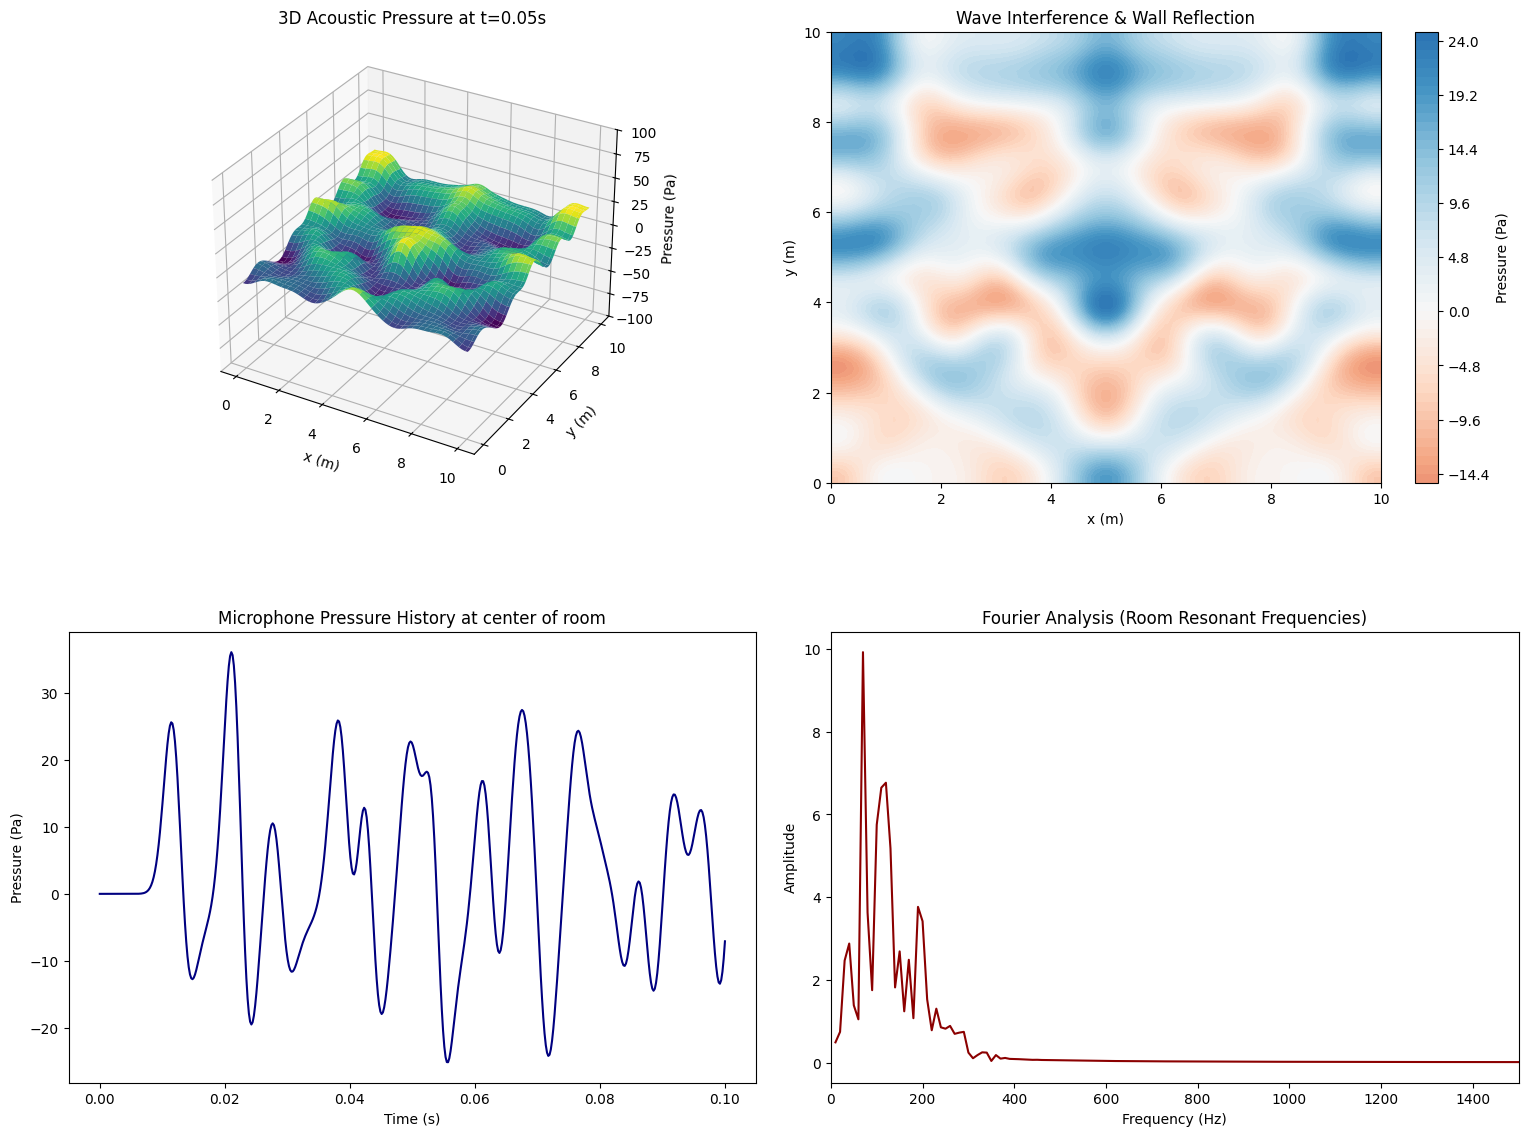

In [20]:
# In this section I am showing/plotting the results

fig = plt.figure(figsize=(16, 12))

# 1. 3D Surface Plot at plot_time
ax1 = fig.add_subplot(2, 2, 1, projection='3d')
surf = ax1.plot_surface(X, Y, P[plot_step, :, :], cmap='viridis', edgecolor='none')
ax1.set_title(f'3D Acoustic Pressure at t={plot_time}s')
ax1.set_xlabel('x (m)'); ax1.set_ylabel('y (m)'); ax1.set_zlabel('Pressure (Pa)')
ax1.set_zlim(-A, A) 

# 2. 2D Contour Plot at plot_time, showing interference and reflections
ax2 = fig.add_subplot(2, 2, 2)
contour = ax2.contourf(X, Y, P[plot_step, :, :], levels=60, cmap='RdBu', vmin=-A/3, vmax=A/3)
fig.colorbar(contour, ax=ax2, label='Pressure (Pa)')
ax2.set_title('Wave Interference & Wall Reflection')
ax2.set_xlabel('x (m)'); ax2.set_ylabel('y (m)')

# 1D Line Plot of P at microphone location over time
ax3 = fig.add_subplot(2, 2, 3)
ax3.plot(time_array, mic_history, color='navy')
ax3.set_title('Microphone Pressure History at center of room')
ax3.set_xlabel('Time (s)'); ax3.set_ylabel('Pressure (Pa)')

# 4. FFT Analysis of microphone signal to identify resonant frequencies

ax4 = fig.add_subplot(2, 2, 4)
ax4.plot(xf[1:], 2.0/N_fft * np.abs(yf[1:N_fft//2]), color='darkred')
ax4.set_title('Fourier Analysis (Room Resonant Frequencies)')
ax4.set_xlabel('Frequency (Hz)'); ax4.set_ylabel('Amplitude')
ax4.set_xlim(0, 1500) 

plt.tight_layout(pad=3.0, h_pad=6.0, w_pad=2.0) #to adjust spacing between subplots
plt.show()

In [21]:
# In this section I am celebrating
print('CW done: I deserve 10000000%')

CW done: I deserve 10000000%
